In [1]:
import numpy as np
import matplotlib.pyplot as plt
import func

import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
})


In [2]:
sig = lambda x: np.tanh(2*x)-0.72948*x
g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig)

In [3]:
d = 200
gamma = 0.5
k = int(gamma*d)
Delta = 0.04

def v_sample(vlaw):
    if vlaw == 'beta_03':
        v = func.v_generate(k, beta=0.3)
    if vlaw == 'beta_07':
        v = func.v_generate(k, beta=0.7)
    if vlaw == 'dense':
        v = np.linspace(2.5, 1, k)
        v /= np.linalg.norm(v)
    if vlaw == 'exp':
        v = np.array([np.exp(-i/20) for i in range(k)])
        v /= np.linalg.norm(v)
    if vlaw == 'exp2':
        v = np.array([np.exp(-i/5) for i in range(k)])
        v /= np.linalg.norm(v)
    return v

In [4]:
# vlaws = ['exp2']
# alphas = [0.5, 1, 2, 4]
# xlims = [20]

# vlaws = ['beta_07', 'dense']
# alphas = [1, 1.5, 2, 2.5]
# xlims = [60, k]

vlaws = ['beta_03']
alphas = [0.5, 1, 1.5, 2]
xlims = [k]

colors = [ "#FF0000", "#AD0000", "#5E0000", "#100000"]
width, height = 6, 4
size = 20

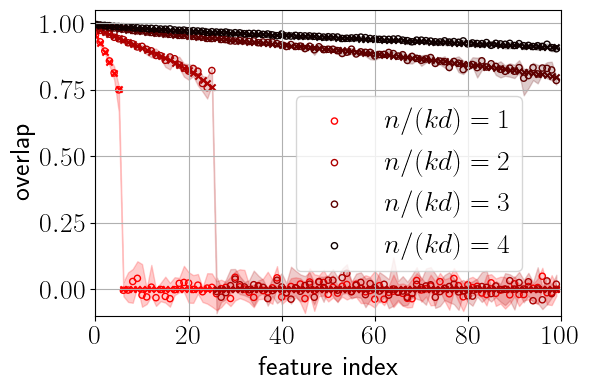

In [ ]:
for vlaw, xlim in zip(vlaws, xlims):
    fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)
    ax.tick_params(axis='both', labelsize=size)
    ax.set_xlabel('feature index', fontsize=size)
    ax.set_ylabel('overlap', fontsize=size)
    plt.xlim(0, xlim)
    ax.set_ylim(-0.1, 1.05)
    ax.grid()

    for alpha, color in zip(alphas, colors):
        v = v_sample(vlaw)
        n = int(alpha*d**2)
        _, qw_theory = func.solve(n, d, Delta, v, g, m_e)

        folder=f'overlaps_data/'
        qw_data = []

        for i in range(16):
            qw_data.append(np.loadtxt(folder+f'{vlaw}_alpha_{alpha}_{i+1}.csv', delimiter=','))
        qw_data = np.array(qw_data)

        # median and quantiles
        q25, median, q75 = np.percentile(qw_data, [25, 50, 75], axis=0)
        # plot
        ax.scatter(np.arange(k), qw_theory, marker='x', s=20, color=color)
        alpha_ = int(2*alpha)
        ax.scatter(np.arange(k), median, marker='o', s=20, facecolors='none', edgecolors=color, label=fr'$n/(kd)={alpha_}$')
        ax.fill_between(np.arange(k), q25, q75, color=color, alpha=0.2)
    plt.legend(fontsize = 20, loc='lower left', bbox_to_anchor=(0.4, 0.10))
    # plt.savefig(f'figs/feature_overlaps_{vlaw}.pdf')
    plt.show()